📊 GLOBAL INFLATION ANALYSIS - EXPLORATORY ANALYSIS
✅ Loaded 7418 observations from 'inflation_cleaned.csv'

🌍 GLOBAL INFLATION TRENDS


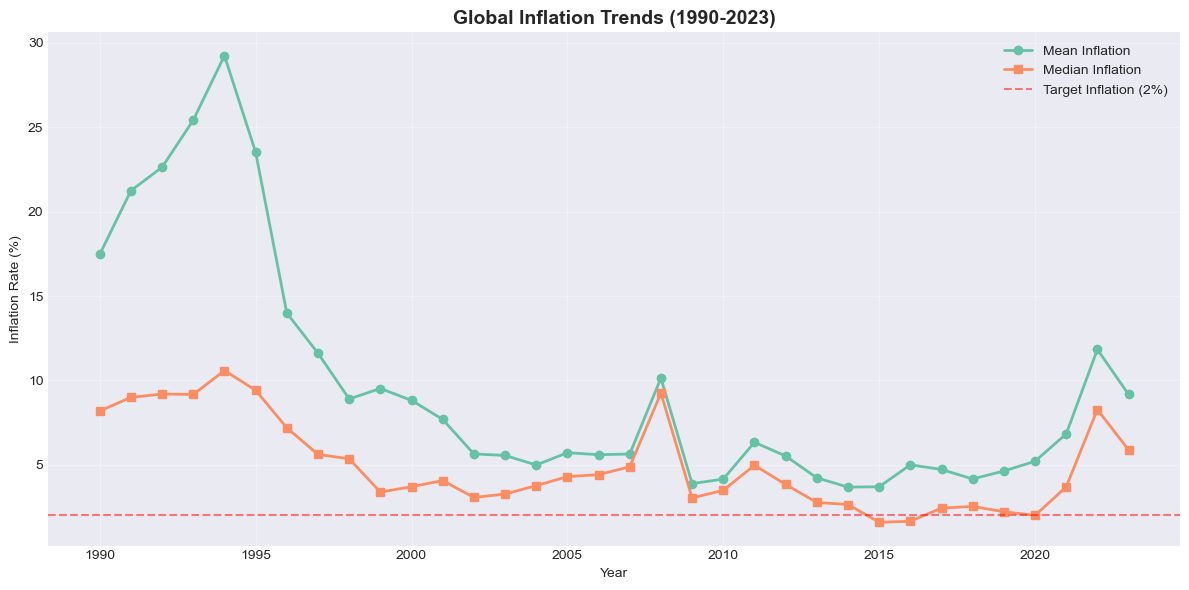

✅ Saved: global_inflation_trend.png

🌎 REGIONAL INFLATION COMPARISON
✅ Saved: regional_inflation_interactive.html


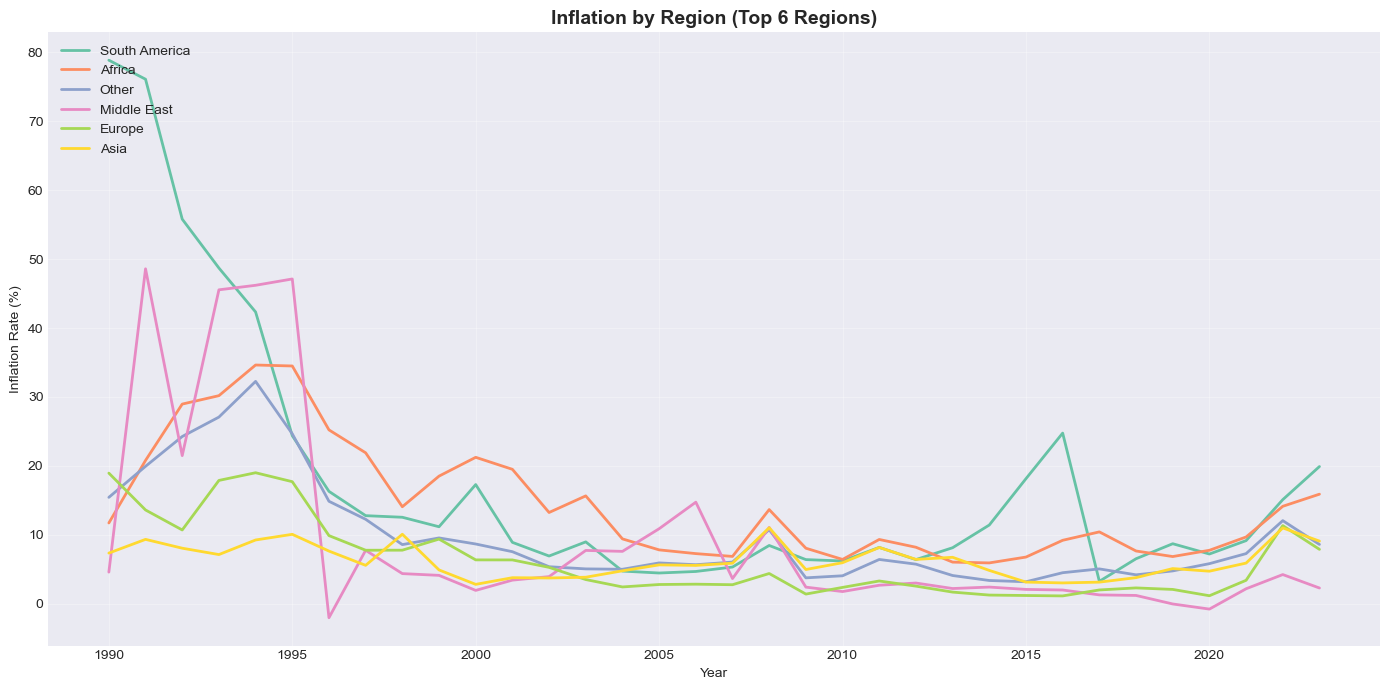

✅ Saved: regional_inflation.png

🏆 COUNTRIES WITH HIGHEST/LOWEST INFLATION

📈 Top 10 Countries with Highest Average Inflation (2013-2023):
    1. Venezuela, RB: 101.17%
    2. Sudan: 73.69%
    3. Argentina: 64.03%
    4. Zimbabwe: 57.25%
    5. South Sudan: 56.48%
    6. Lebanon: 55.14%
    7. Suriname: 31.96%
    8. Iran, Islamic Rep.: 27.36%
    9. Syrian Arab Republic: 24.22%
   10. Turkiye: 21.14%

📉 Top 10 Countries with Lowest Average Inflation (2013-2023):
    1. Cyprus: 0.97%
    2. Greece: 0.94%
    3. Benin: 0.90%
    4. Grenada: 0.74%
    5. New Caledonia: 0.65%
    6. Aruba: 0.64%
    7. Brunei Darussalam: 0.59%
    8. Switzerland: 0.44%
    9. St. Kitts and Nevis: 0.36%
   10. Cayman Islands: 0.12%


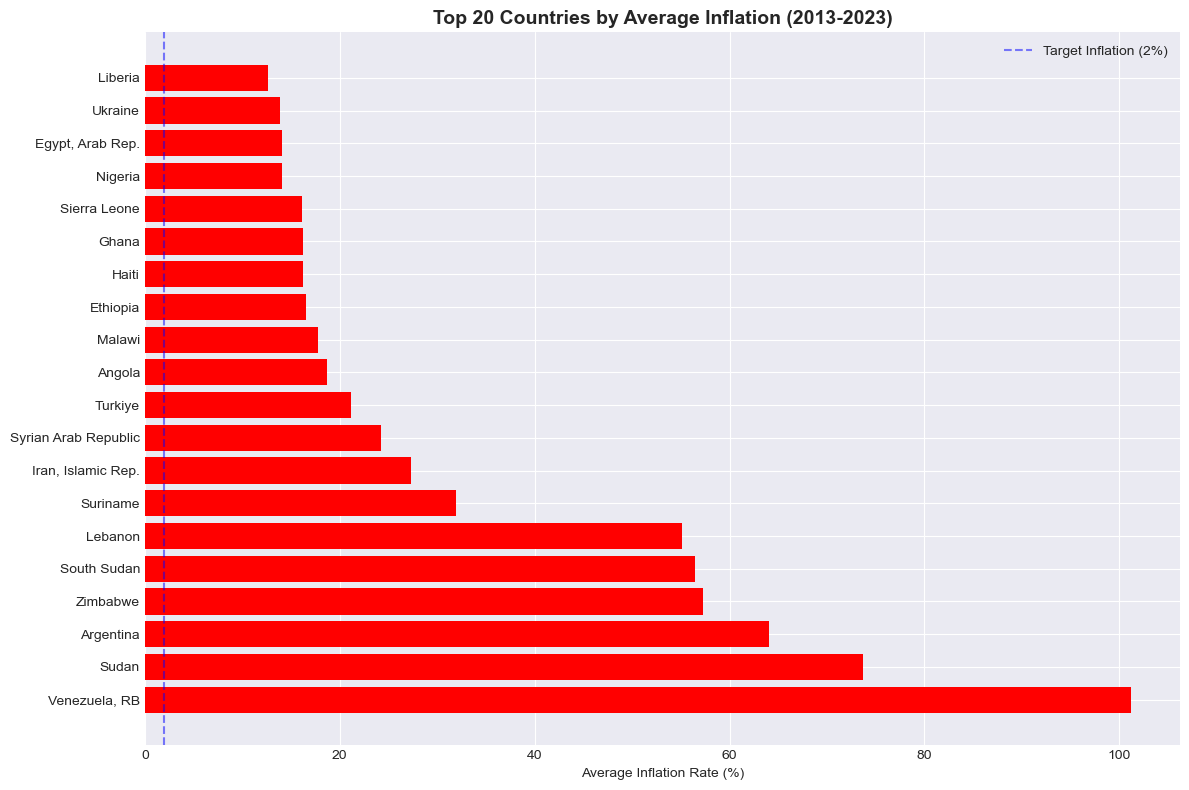

✅ Saved: top_inflation_countries.png

🔥 INFLATION HEATMAP


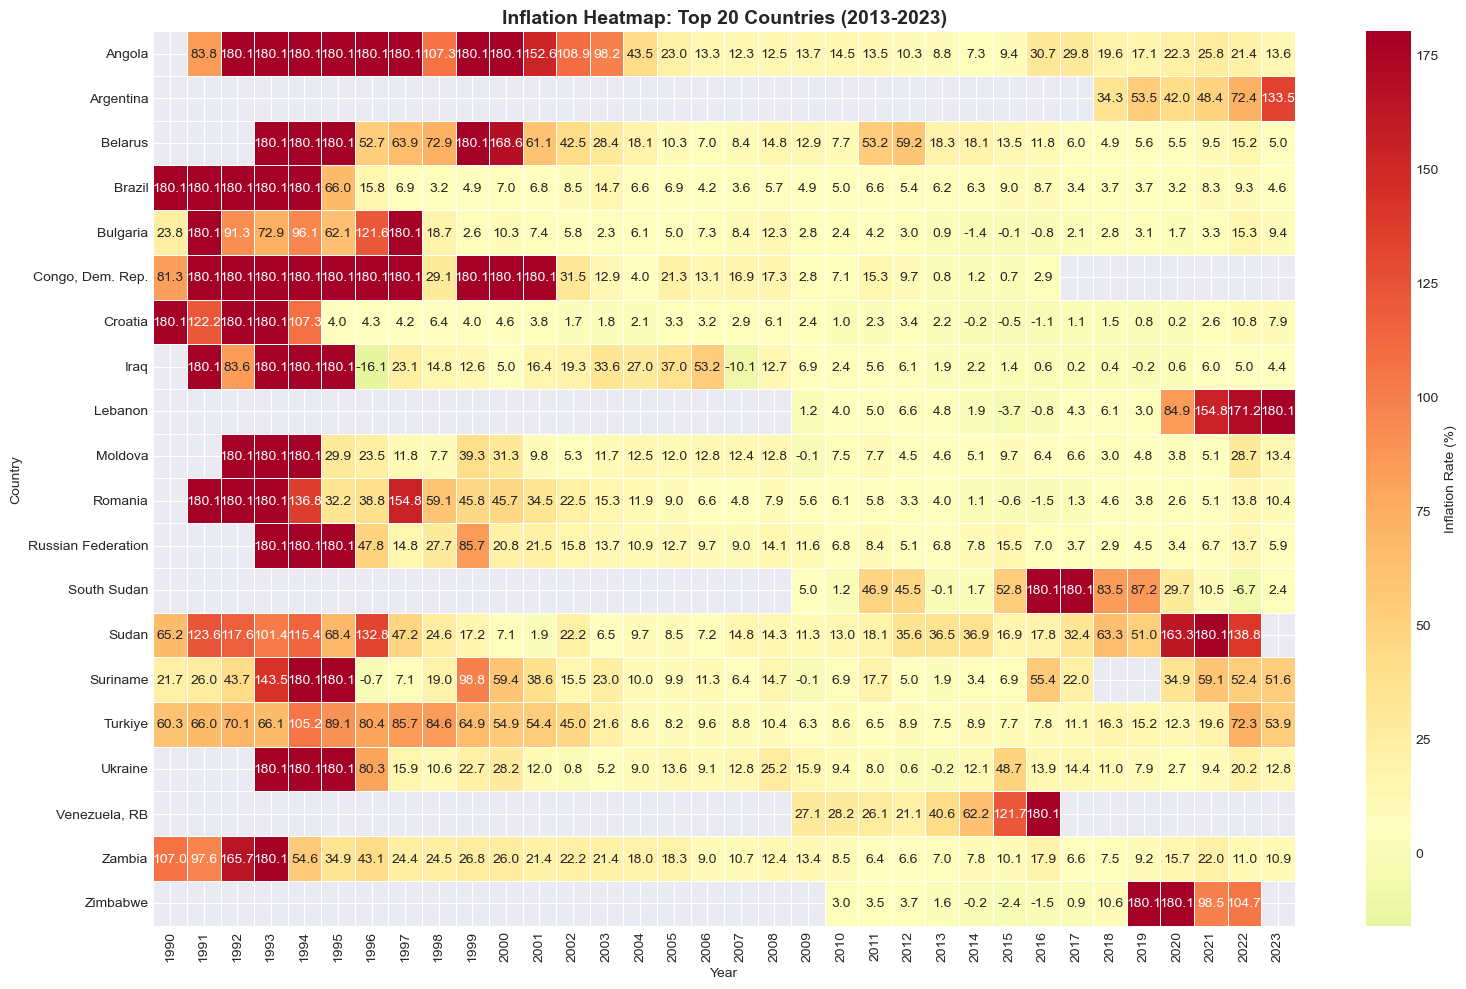

✅ Saved: inflation_heatmap.png

📈 INFLATION VS GDP GROWTH


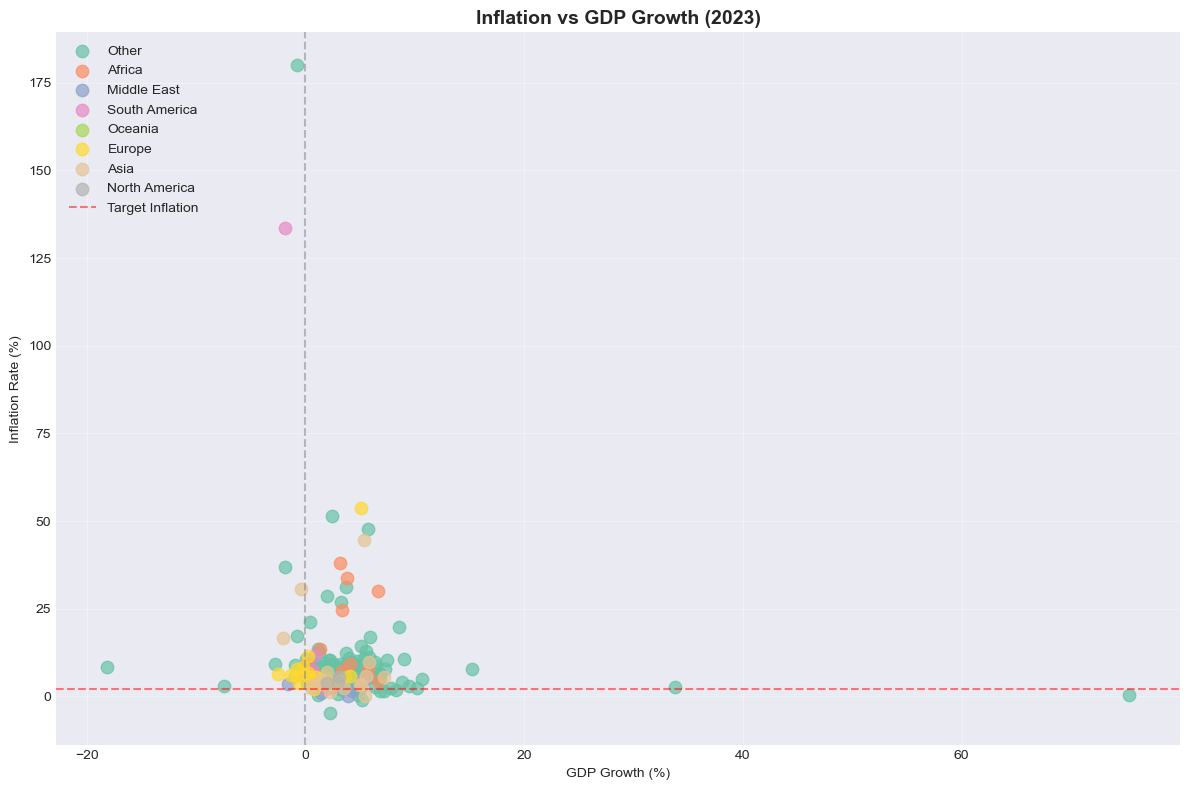

✅ Saved: inflation_vs_gdp.png

📊 SUMMARY STATISTICS

📈 Overall Inflation Statistics (1990-2023):
count    7418.00
mean        9.14
std        21.87
min       -16.86
25%         2.10
50%         4.21
75%         8.08
max       180.14
Name: Inflation_Rate_Capped, dtype: float64

🌍 Inflation by Region (1990-2023):
                mean  median    std
Region                             
South America  17.56    6.53  33.55
Africa         14.34    6.72  28.10
Other           9.15    4.42  21.88
Middle East     8.13    2.33  28.02
Europe          6.27    2.29  17.95
Asia            6.22    4.29   7.26
North America   4.76    2.88   6.14
Oceania         2.59    2.31   1.61

📅 Inflation by Decade:
Decade
1990    18.20
2000     6.35
2010     4.62
2020     8.26
Name: Inflation_Rate_Capped, dtype: float64

✅ Exploratory analysis complete!


In [1]:
# ============================================
# 03_exploratory_analysis.ipynb
# Global Inflation Analysis - Exploratory Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("=" * 60)
print("📊 GLOBAL INFLATION ANALYSIS - EXPLORATORY ANALYSIS")
print("=" * 60)

# ============================================
# 1. Load Cleaned Data (from same folder)
# ============================================

df = pd.read_csv('inflation_cleaned.csv')   # <-- No path, just filename
print(f"✅ Loaded {len(df)} observations from 'inflation_cleaned.csv'")

# ============================================
# 2. Global Inflation Trends
# ============================================

print("\n" + "=" * 60)
print("🌍 GLOBAL INFLATION TRENDS")
print("=" * 60)

# Global average inflation by year
global_trend = df.groupby('Year')['Inflation_Rate_Capped'].mean().reset_index()
global_trend.columns = ['Year', 'Avg_Inflation']

# Global median inflation by year (more robust to outliers)
global_median = df.groupby('Year')['Inflation_Rate_Capped'].median().reset_index()
global_median.columns = ['Year', 'Median_Inflation']

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(global_trend['Year'], global_trend['Avg_Inflation'],
        marker='o', linewidth=2, label='Mean Inflation')
ax.plot(global_median['Year'], global_median['Median_Inflation'],
        marker='s', linewidth=2, label='Median Inflation')
ax.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Target Inflation (2%)')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.set_title('Global Inflation Trends (1990-2023)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('global_inflation_trend.png', dpi=300, bbox_inches='tight')   # <-- local file
plt.show()
print("✅ Saved: global_inflation_trend.png")

# ============================================
# 3. Regional Comparison
# ============================================

print("\n" + "=" * 60)
print("🌎 REGIONAL INFLATION COMPARISON")
print("=" * 60)

# Average inflation by region over time
regional_trend = df.groupby(['Year', 'Region'])['Inflation_Rate_Capped'].mean().reset_index()

# Plot with Plotly (interactive) – save HTML locally
fig = px.line(
    regional_trend,
    x='Year',
    y='Inflation_Rate_Capped',
    color='Region',
    title='Inflation by Region (1990-2023)',
    labels={'Inflation_Rate_Capped': 'Inflation Rate (%)'},
    line_shape='linear'
)
fig.write_html('regional_inflation_interactive.html')   # <-- local HTML
print("✅ Saved: regional_inflation_interactive.html")
fig.show()

# Static version
fig2, ax2 = plt.subplots(figsize=(14, 7))

# Get top regions by average inflation
top_regions = df.groupby('Region')['Inflation_Rate_Capped'].mean().sort_values(ascending=False).index[:6]

for region in top_regions:
    region_data = df[df['Region'] == region].groupby('Year')['Inflation_Rate_Capped'].mean()
    ax2.plot(region_data.index, region_data.values, linewidth=2, label=region)

ax2.set_xlabel('Year')
ax2.set_ylabel('Inflation Rate (%)')
ax2.set_title('Inflation by Region (Top 6 Regions)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regional_inflation.png', dpi=300, bbox_inches='tight')   # <-- local file
plt.show()
print("✅ Saved: regional_inflation.png")

# ============================================
# 4. Top/Bottom Inflation Countries
# ============================================

print("\n" + "=" * 60)
print("🏆 COUNTRIES WITH HIGHEST/LOWEST INFLATION")
print("=" * 60)

# Average inflation by country (last 10 years)
recent_years = df[df['Year'] >= 2013]
country_avg = recent_years.groupby('Country')['Inflation_Rate_Capped'].mean().sort_values(ascending=False)

print("\n📈 Top 10 Countries with Highest Average Inflation (2013-2023):")
for i, (country, rate) in enumerate(country_avg.head(10).items(), 1):
    print(f"   {i:2d}. {country}: {rate:.2f}%")

print("\n📉 Top 10 Countries with Lowest Average Inflation (2013-2023):")
for i, (country, rate) in enumerate(country_avg.tail(10).items(), 1):
    print(f"   {i:2d}. {country}: {rate:.2f}%")

# Plot top 20
fig3, ax3 = plt.subplots(figsize=(12, 8))
top_20 = country_avg.head(20)
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in top_20.values]
ax3.barh(top_20.index, top_20.values, color=colors)
ax3.set_xlabel('Average Inflation Rate (%)')
ax3.set_title('Top 20 Countries by Average Inflation (2013-2023)', fontsize=14, fontweight='bold')
ax3.axvline(x=2, color='blue', linestyle='--', alpha=0.5, label='Target Inflation (2%)')
ax3.legend()
plt.tight_layout()
plt.savefig('top_inflation_countries.png', dpi=300, bbox_inches='tight')   # <-- local file
plt.show()
print("✅ Saved: top_inflation_countries.png")

# ============================================
# 5. Inflation Heatmap (Top Countries)
# ============================================

print("\n" + "=" * 60)
print("🔥 INFLATION HEATMAP")
print("=" * 60)

# Select top 20 countries (by recent inflation)
top_countries = df.groupby('Country')['Inflation_Rate_Capped'].mean().nlargest(20).index
heatmap_data = df[df['Country'].isin(top_countries)].pivot(
    index='Country',
    columns='Year',
    values='Inflation_Rate_Capped'
)

fig4, ax4 = plt.subplots(figsize=(16, 10))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',  # Red = high inflation, Green = low
    center=5,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Inflation Rate (%)'}
)
ax4.set_title('Inflation Heatmap: Top 20 Countries (2013-2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inflation_heatmap.png', dpi=300, bbox_inches='tight')   # <-- local file
plt.show()
print("✅ Saved: inflation_heatmap.png")

# ============================================
# 6. Inflation vs GDP Growth (Scatter)
# ============================================

print("\n" + "=" * 60)
print("📈 INFLATION VS GDP GROWTH")
print("=" * 60)

# Latest year data
latest_year = df['Year'].max()
latest_data = df[df['Year'] == latest_year].dropna(subset=['GDP_Growth'])

fig5, ax5 = plt.subplots(figsize=(12, 8))

# Scatter with region coloring
regions = latest_data['Region'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))

for i, region in enumerate(regions):
    region_data = latest_data[latest_data['Region'] == region]
    ax5.scatter(
        region_data['GDP_Growth'],
        region_data['Inflation_Rate_Capped'],
        label=region,
        alpha=0.7,
        s=80
    )

ax5.set_xlabel('GDP Growth (%)')
ax5.set_ylabel('Inflation Rate (%)')
ax5.set_title(f'Inflation vs GDP Growth ({latest_year})', fontsize=14, fontweight='bold')
ax5.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Target Inflation')
ax5.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax5.legend(loc='upper left')
ax5.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('inflation_vs_gdp.png', dpi=300, bbox_inches='tight')   # <-- local file
plt.show()
print("✅ Saved: inflation_vs_gdp.png")

# ============================================
# 7. Summary Statistics
# ============================================

print("\n" + "=" * 60)
print("📊 SUMMARY STATISTICS")
print("=" * 60)

print("\n📈 Overall Inflation Statistics (1990-2023):")
print(df['Inflation_Rate_Capped'].describe().round(2))

print("\n🌍 Inflation by Region (1990-2023):")
region_stats = df.groupby('Region')['Inflation_Rate_Capped'].agg(['mean', 'median', 'std']).round(2)
print(region_stats.sort_values('mean', ascending=False))

print("\n📅 Inflation by Decade:")
decade_stats = df.groupby('Decade')['Inflation_Rate_Capped'].mean().round(2)
print(decade_stats)

print("\n✅ Exploratory analysis complete!")